In [224]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [225]:
ds = pd.read_csv("data.csv")

In [226]:
ds.info

<bound method DataFrame.info of             Date  Close/Last    Volume    Open    High     Low
0     10/28/2022      1648.3  186519.0  1667.2  1670.9  1640.7
1     10/27/2022      1668.8  180599.0  1668.8  1674.8  1658.5
2     10/26/2022      1669.2  183453.0  1657.7  1679.4  1653.8
3     10/25/2022      1658.0  178706.0  1654.5  1666.8  1641.2
4     10/24/2022      1654.1  167448.0  1662.9  1675.5  1648.0
...          ...         ...       ...     ...     ...     ...
2542  11/06/2012      1715.0  163585.0  1685.4  1720.9  1683.5
2543  11/05/2012      1683.2  109647.0  1676.7  1686.2  1672.5
2544  11/02/2012      1675.2  205777.0  1715.6  1717.2  1674.8
2545  11/01/2012      1715.5  105904.0  1720.4  1727.5  1715.1
2546  10/31/2012      1719.1  110928.0  1710.3  1726.6  1709.8

[2547 rows x 6 columns]>

In [227]:
ds["Date"].unique()

array(['10/28/2022', '10/27/2022', '10/26/2022', ..., '11/02/2012',
       '11/01/2012', '10/31/2012'], dtype=object)

In [228]:
ds["Close/Last"].unique()

array([1648.3, 1668.8, 1669.2, ..., 1715. , 1715.5, 1719.1])

In [229]:
ds["Volume"].unique()

array([186519., 180599., 183453., ..., 205777., 105904., 110928.])

In [230]:
mean = int(ds["Volume"].mean())

In [231]:
mean

182067

In [232]:
ds["Volume"].fillna(mean , inplace = True)

C:\Users\shrey\AppData\Local\Temp\ipykernel_17728\1542567439.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ds["Volume"].fillna(mean , inplace = True)


In [233]:
ds.info

<bound method DataFrame.info of             Date  Close/Last    Volume    Open    High     Low
0     10/28/2022      1648.3  186519.0  1667.2  1670.9  1640.7
1     10/27/2022      1668.8  180599.0  1668.8  1674.8  1658.5
2     10/26/2022      1669.2  183453.0  1657.7  1679.4  1653.8
3     10/25/2022      1658.0  178706.0  1654.5  1666.8  1641.2
4     10/24/2022      1654.1  167448.0  1662.9  1675.5  1648.0
...          ...         ...       ...     ...     ...     ...
2542  11/06/2012      1715.0  163585.0  1685.4  1720.9  1683.5
2543  11/05/2012      1683.2  109647.0  1676.7  1686.2  1672.5
2544  11/02/2012      1675.2  205777.0  1715.6  1717.2  1674.8
2545  11/01/2012      1715.5  105904.0  1720.4  1727.5  1715.1
2546  10/31/2012      1719.1  110928.0  1710.3  1726.6  1709.8

[2547 rows x 6 columns]>

In [234]:
ds["Volume"].unique()

array([186519., 180599., 183453., ..., 205777., 105904., 110928.])

In [235]:
ds["Volume"] = ds["Volume"].astype(float)

In [236]:
ds["Volume"].unique()

array([186519., 180599., 183453., ..., 205777., 105904., 110928.])

In [237]:
ds.duplicated().unique()

array([False])

In [238]:
ds.drop_duplicates(inplace = True)

In [239]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2547 entries, 0 to 2546
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        2547 non-null   object 
 1   Close/Last  2547 non-null   float64
 2   Volume      2547 non-null   float64
 3   Open        2547 non-null   float64
 4   High        2547 non-null   float64
 5   Low         2547 non-null   float64
dtypes: float64(5), object(1)
memory usage: 119.5+ KB


In [240]:
ds['Date'] = pd.to_datetime(ds['Date'])


In [241]:
ds.duplicated().unique()

array([False])

In [242]:
ds["Close/Last"] = ds["Close/Last"].astype(float)

In [243]:
ds["Open"] = ds["Open"].astype(float)

In [244]:
ds["High"] = ds["High"].astype(float)

In [245]:
import sklearn as skl



In [246]:
from sklearn.impute import SimpleImputer
Si = SimpleImputer(missing_values = np.nan , strategy = 'mean')
columns = ["Close/Last","High","Low"]
ds[columns] = Si.fit_transform(ds[columns])

In [247]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2547 entries, 0 to 2546
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        2547 non-null   datetime64[ns]
 1   Close/Last  2547 non-null   float64       
 2   Volume      2547 non-null   float64       
 3   Open        2547 non-null   float64       
 4   High        2547 non-null   float64       
 5   Low         2547 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 119.5 KB


In [248]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
One_hot_encoded = ohe.fit_transform(ds[['Date']])
result_ds = pd.concat([ds] , axis = 1)

In [249]:
result_ds

,Date,Close/Last,Volume,Open,High,Low
0,2022-10-28,1648.3,186519.0,1667.2,1670.9,1640.7
1,2022-10-27,1668.8,180599.0,1668.8,1674.8,1658.5
2,2022-10-26,1669.2,183453.0,1657.7,1679.4,1653.8
3,2022-10-25,1658.0,178706.0,1654.5,1666.8,1641.2
4,2022-10-24,1654.1,167448.0,1662.9,1675.5,1648.0
...,...,...,...,...,...,...
2542,2012-11-06,1715.0,163585.0,1685.4,1720.9,1683.5
2543,2012-11-05,1683.2,109647.0,1676.7,1686.2,1672.5
2544,2012-11-02,1675.2,205777.0,1715.6,1717.2,1674.8
2545,2012-11-01,1715.5,105904.0,1720.4,1727.5,1715.1


In [250]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
ds["Close/Last"] = le.fit_transform(ds["Close/Last"])


In [251]:
ds

,Date,Close/Last,Volume,Open,High,Low
0,2022-10-28,1383,186519.0,1667.2,1670.9,1640.7
1,2022-10-27,1412,180599.0,1668.8,1674.8,1658.5
2,2022-10-26,1413,183453.0,1657.7,1679.4,1653.8
3,2022-10-25,1395,178706.0,1654.5,1666.8,1641.2
4,2022-10-24,1388,167448.0,1662.9,1675.5,1648.0
...,...,...,...,...,...,...
2542,2012-11-06,1488,163585.0,1685.4,1720.9,1683.5
2543,2012-11-05,1440,109647.0,1676.7,1686.2,1672.5
2544,2012-11-02,1426,205777.0,1715.6,1717.2,1674.8
2545,2012-11-01,1489,105904.0,1720.4,1727.5,1715.1


In [252]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
columns = ["Close/Last","Open","High","Low"]
ds[columns] = sc.fit_transform(ds[columns])


In [253]:
ds

,Date,Close/Last,Volume,Open,High,Low
0,2022-10-28,0.722421,186519.0,0.895653,0.867932,0.839177
1,2022-10-27,0.773543,180599.0,0.901898,0.883056,0.909369
2,2022-10-26,0.775306,183453.0,0.858571,0.900894,0.890835
3,2022-10-25,0.743575,178706.0,0.846080,0.852033,0.841149
4,2022-10-24,0.731235,167448.0,0.878868,0.885771,0.867964
...,...,...,...,...,...,...
2542,2012-11-06,0.907518,163585.0,0.966694,1.061826,1.007953
2543,2012-11-05,0.822903,109647.0,0.932735,0.927264,0.964576
2544,2012-11-02,0.798223,205777.0,1.084575,1.047478,0.973645
2545,2012-11-01,0.909281,105904.0,1.103312,1.087420,1.132562


In [254]:
print(sc.mean_)
print(sc.scale_)

[ 973.1923832  1437.74303102 1447.08323518 1427.89199058]
[567.26959255 256.18963063 257.87352043 253.5913187 ]


In [255]:
mean = ds["Volume"].mean()
print (mean)
std= ds["Volume"].std()
print(std)

182067.65842167256
96839.01421516293


In [256]:
X = (1442 - std)/mean
X

-0.5239646351370182

In [257]:
ds

,Date,Close/Last,Volume,Open,High,Low
0,2022-10-28,0.722421,186519.0,0.895653,0.867932,0.839177
1,2022-10-27,0.773543,180599.0,0.901898,0.883056,0.909369
2,2022-10-26,0.775306,183453.0,0.858571,0.900894,0.890835
3,2022-10-25,0.743575,178706.0,0.846080,0.852033,0.841149
4,2022-10-24,0.731235,167448.0,0.878868,0.885771,0.867964
...,...,...,...,...,...,...
2542,2012-11-06,0.907518,163585.0,0.966694,1.061826,1.007953
2543,2012-11-05,0.822903,109647.0,0.932735,0.927264,0.964576
2544,2012-11-02,0.798223,205777.0,1.084575,1.047478,0.973645
2545,2012-11-01,0.909281,105904.0,1.103312,1.087420,1.132562


In [258]:
#dividing training and testing datasets
# 1.Divide dataset into independent (input) and dependent(output)variaables
X = ds[["Close/Last","Open","High","Low"]]
y =ds[["Volume"]]

In [259]:
y

,Volume
0,186519.0
1,180599.0
2,183453.0
3,178706.0
4,167448.0
...,...
2542,163585.0
2543,109647.0
2544,205777.0
2545,105904.0


In [260]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.02,random_state = 0)

In [261]:
X

,Close/Last,Open,High,Low
0,0.722421,0.895653,0.867932,0.839177
1,0.773543,0.901898,0.883056,0.909369
2,0.775306,0.858571,0.900894,0.890835
3,0.743575,0.846080,0.852033,0.841149
4,0.731235,0.878868,0.885771,0.867964
...,...,...,...,...
2542,0.907518,0.966694,1.061826,1.007953
2543,0.822903,0.932735,0.927264,0.964576
2544,0.798223,1.084575,1.047478,0.973645
2545,0.909281,1.103312,1.087420,1.132562


In [262]:
y_test

,Volume
1151,361181.0
390,141968.0
878,241502.0
1261,377535.0
2290,121111.0
385,171089.0
1205,305093.0
135,135491.0
1099,223323.0
1524,127971.0


In [267]:
import seaborn as sns

In [295]:
X = ds[["Close/Last","Open","High","Low"]]
y = ds[["Volume"]]

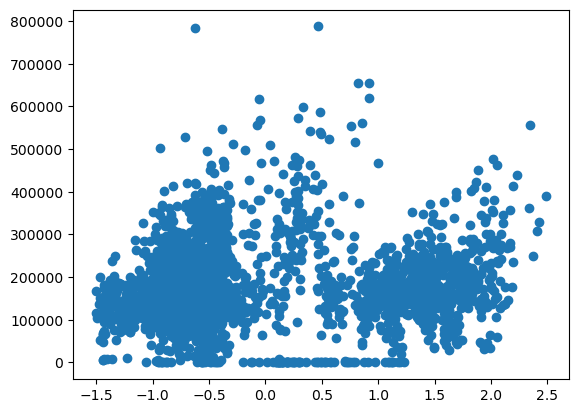

In [303]:
plt.scatter(X[["Open"]],y)

In [271]:
type(X)[

pandas.core.frame.DataFrame

In [273]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X ,y )

LinearRegression()

In [275]:
reg.coef_

array([[  59596.45603904,  239025.40402398,  462155.65629903,
        -752406.43933722]])

In [277]:
reg.intercept_

array([182067.65842167])

In [279]:
result = (59596.45603904 * 11) + 182067.65842167
result

837628.67485111

ConversionError: Failed to convert value(s) to axis units:            Date  Close/Last      Open      High       Low
0    2022-10-28    0.722421  0.895653  0.867932  0.839177
1    2022-10-27    0.773543  0.901898  0.883056  0.909369
2    2022-10-26    0.775306  0.858571  0.900894  0.890835
3    2022-10-25    0.743575  0.846080  0.852033  0.841149
4    2022-10-24    0.731235  0.878868  0.885771  0.867964
...         ...         ...       ...       ...       ...
2542 2012-11-06    0.907518  0.966694  1.061826  1.007953
2543 2012-11-05    0.822903  0.932735  0.927264  0.964576
2544 2012-11-02    0.798223  1.084575  1.047478  0.973645
2545 2012-11-01    0.909281  1.103312  1.087420  1.132562
2546 2012-10-31    0.925147  1.063888  1.083930  1.111663

[2547 rows x 5 columns]

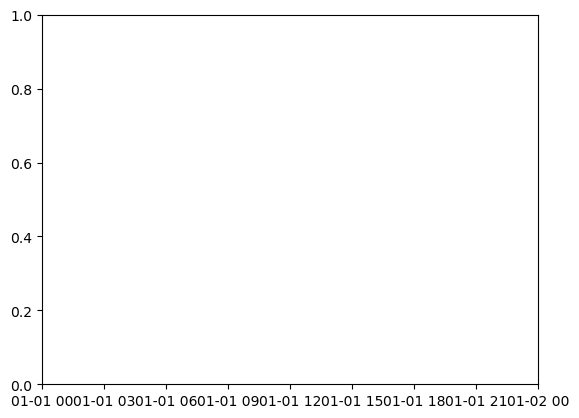

In [211]:
plt.scatter (X , y)
plt.plot(X,reg.predict(X))

In [281]:
reg.predict(X_test)

array([[204742.06966172],
       [136489.09397833],
       [166899.19608446],
       [184781.55899359],
       [213609.87876528],
       [123673.10930534],
       [182535.04597359],
       [170961.91720512],
       [167591.48796105],
       [161865.21201537],
       [209034.59860782],
       [163434.5148407 ],
       [159433.97116878],
       [146076.06431776],
       [184457.17201279],
       [218344.89771352],
       [192463.92062197],
       [180250.85084535],
       [151520.50129176],
       [187831.06588101],
       [161231.63194459],
       [173754.54883074],
       [172839.23790632],
       [162506.54881889],
       [164765.26770329],
       [134912.93759914],
       [288166.19842398],
       [157720.91377877],
       [186092.69606822],
       [180534.65179606],
       [142886.12754891],
       [156079.75213693],
       [201838.18308952],
       [157387.95885787],
       [148220.61767432],
       [174596.30558978],
       [175332.98769118],
       [203061.25532238],
       [1555

In [ ]:
#multiple linear regression

In [283]:
X_train

,Close/Last,Open,High,Low
1498,-1.024544,-0.818702,-0.829799,-0.815848
117,1.411688,1.618165,1.596584,1.546614
1239,-0.266527,-0.542344,-0.565328,-0.526012
1710,-1.632720,-1.360098,-1.371925,-1.336371
2400,0.272900,-0.272622,-0.193828,-0.287439
...,...,...,...,...
1033,-1.183198,-0.912383,-0.924031,-0.904179
1731,-1.667977,-1.473296,-1.431645,-1.449939
763,0.450945,0.193439,0.162936,0.231506
835,0.297579,-0.155522,-0.173276,-0.159280


In [285]:
X_test

,Close/Last,Open,High,Low
1151,0.077225,-0.421731,-0.418745,-0.415203
390,1.016814,1.204799,1.125811,1.215373
878,-0.425181,-0.606360,-0.619619,-0.586739
1261,-0.592650,-0.621192,-0.633191,-0.636820
2290,0.163604,-0.410801,-0.367557,-0.385234
385,1.238931,1.332439,1.352666,1.429891
1205,-0.000339,-0.430708,-0.441237,-0.408500
135,1.838293,2.110768,2.155773,2.155074
1099,-0.545054,-0.626267,-0.653356,-0.624201
1524,-0.719574,-0.687159,-0.709973,-0.684534


In [291]:
myinput = [[1000 , 8000, 1000 , 1000]]
X.columns
myds = pd.DataFrame(columns = X.columns , data = myinput)
myds

,Close/Last,Open,High,Low
0,1000,8000,1000,1000


In [293]:
result = reg.predict(myds)
print(result)

[[1.68173097e+09]]
